****Machine Learning Model Building (After EDA):****

**1.Import Required Libraries**

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

**2.Load Clean Dataset**

In [4]:
df = pd.read_csv("loan_cleaned.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Loan_to_Income,Credit_Category,Income_Group
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,Full-time,Divorced,Yes,Yes,Other,Yes,0,0.588262,Poor,High
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,Full-time,Married,No,No,Other,Yes,0,2.467481,Poor,Medium
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,Unemployed,Divorced,Yes,Yes,Auto,No,1,1.534154,Poor,High
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,Full-time,Married,No,No,Business,No,0,1.412638,Good,Medium
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,Unemployed,Divorced,No,Yes,Auto,No,0,0.447179,Average,Low


**3.Remove Unnecessary Columns**

In [5]:
#LoanID is unique and does not help prediction.
df.drop("LoanID", axis=1, inplace=True)

**4.Convert Categorical Variables**

In [6]:
df.select_dtypes(include='object').columns

Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Credit_Category',
       'Income_Group'],
      dtype='object')

*-One-Hot Encoding*

In [7]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [8]:
df_encoded.shape

(255347, 31)

**5.Separate Features and Target**

In [9]:
X = df_encoded.drop("Default", axis=1)

y = df_encoded["Default"]

**6.Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**7.Baseline Model: Logistic Regression**

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

*-Evaluation*

In [13]:
print("Accuracy:",
      accuracy_score(y_test,y_pred_lr))

print(classification_report(
      y_test,
      y_pred_lr))

Accuracy: 0.8867045232034463
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.61      0.07      0.12      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070



*-Confusion Matrix*

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm)

[[44876   263]
 [ 5523   408]]


**8.Random Forest Model**

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

*-Evaluate Random Forest*

In [18]:
print(
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

0.8856275700019581
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.04      0.08      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070



**9.ROC-AUC Score**

In [17]:
y_prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob
)

0.741759787763464

**10.Feature Importance**

In [19]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
6,InterestRate,0.107577
9,Loan_to_Income,0.105180
1,Income,0.094318
0,Age,0.092953
2,LoanAmount,0.091287
4,MonthsEmployed,0.086668
3,CreditScore,0.084849
8,DTIRatio,0.076589
7,LoanTerm,0.035071
5,NumCreditLines,0.028478


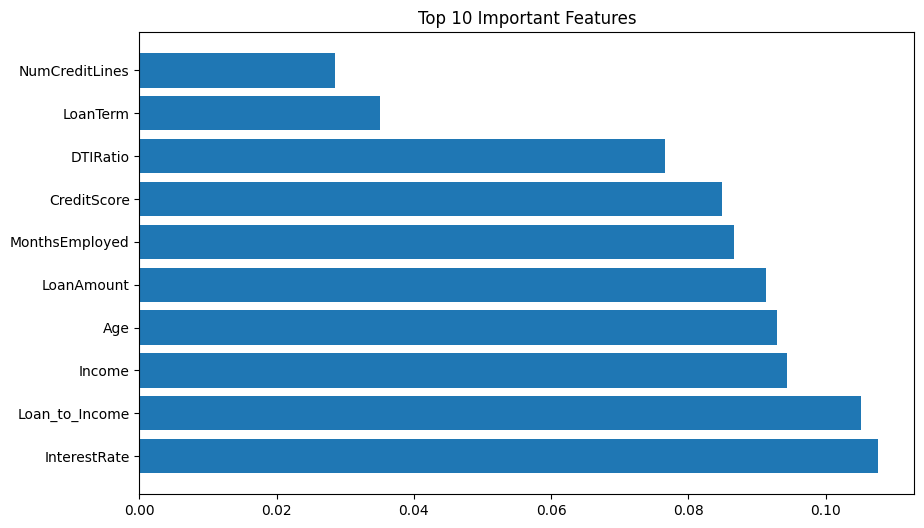

In [20]:
#Visualize Feature Importance
import matplotlib.pyplot as plt

top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("Top 10 Important Features")

plt.show()

**11.Create Risk Score**

In [21]:
df_encoded["Risk_Score"] = rf.predict_proba(X)[:,1]

In [22]:
#Risk Segmentation
df_encoded['Risk_Category'] = pd.cut(
    df_encoded['Risk_Score'],
    bins=[0,0.3,0.6,1],
    labels=[
        'Low Risk',
        'Medium Risk',
        'High Risk'
    ]
)

**12.Export Final Dataset**

In [23]:
df_encoded.to_csv(
    "loan_dashboard_data.csv",
    index=False
)

In [24]:
df_encoded.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes,Credit_Category_Excellent,Credit_Category_Good,Credit_Category_Poor,Income_Group_Low,Income_Group_Medium,Risk_Score,Risk_Category
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,False,True,True,False,False,True,False,False,0.010,Low Risk
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,True,True,False,False,True,False,True,0.020,Low Risk
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,False,False,False,False,False,True,False,False,0.735,High Risk
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,False,False,False,True,False,False,True,0.040,Low Risk
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,False,False,False,False,False,False,True,False,0.025,Low Risk
